# 09 — Per-user typed heads: built-in training for enterprise contexts

Enterprise users solve their own small or big problems with a smaller,
more consistent vocabulary. The ewm-sm apparatus stays **shared and
vocabulary-agnostic** (`docs/SEPARATION.md`); what adapts per user is
the **router** — here, a tiny typed head trained on the user's own
analytical context.

This notebook exercises `trainer/user_models.py`, the built-in support:

```text
UserContext -> VocabAdapter (user codebook)
            -> collect_user_dataset (teacher loop -> routing_log.jsonl)
            -> train_user_head (distill the teacher's soft labels)
            -> register_user_model (registry)
            -> UserHeadRouter.load(user_id) (serve)
```

Two synthetic enterprise users — `acme-finance` and `medco-clinical` —
each with their own small codebook and query bank, each get their own
head; then we cross-evaluate to show the per-user model matters.

Registry layout:

```text
~/.cache/ewm-models/<user_id>/{config.json, trajectory.json,
                              routing_log.jsonl, typed_head.pt, metrics.json}
```

In [1]:
import os, sys, json

# Same GPU pin as notebooks 21–23: with PCI_BUS_ID on this machine the
# Quadro M1200 is device 0 and the RTX 3060 is device 1.
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")

import numpy as np

EWM_SM = "/home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine"
sys.path.insert(0, EWM_SM)

from trainer import (
    DEFAULT_MODEL_ROOT,
    EwmScene,
    StructuralLlmRouter,
    UserContext,
    UserHeadRouter,
    VocabAdapter,
    collect_user_dataset,
    evaluate_router_on_log,
    register_user_model,
    train_user_head,
)

print("model root:", DEFAULT_MODEL_ROOT)
ewm = EwmScene()
teacher = StructuralLlmRouter(max_new_tokens=96)   # shared prompted teacher
print("teacher mode:", "mock" if teacher.mock else "real", "|", teacher.model_id)

model root: /home/alexmy/.cache/ewm-models


teacher mode: real | Qwen/Qwen2.5-1.5B-Instruct


In [2]:
USERS = [
    UserContext(
        user_id="acme-finance",
        vocab=[f"fin_{i}" for i in range(48)],
        queries=[
            "What is EBITDA?",
            "Explain our revenue recognition policy.",
            "What is the current guidance on the debt-to-equity ratio?",
            "Define working capital.",
            "Summarize the Q3 cash flow statement.",
            "What is the difference between OpEx and CapEx?",
            "How do we calculate net margin?",
            "What drives churn in the finance segment?",
        ],
    ),
    UserContext(
        user_id="medco-clinical",
        vocab=[f"med_{i}" for i in range(48)],
        queries=[
            "What are the contraindications for beta blockers?",
            "Summarize the phase II trial protocol.",
            "What is the normal range for serum creatinine?",
            "Define the inclusion criteria for cohort A.",
            "How do we stage chronic kidney disease?",
            "What are the side effects of the study drug?",
            "Explain the informed consent process.",
            "What is the readmission rate benchmark?",
        ],
    ),
]
print("users:", [u.user_id for u in USERS])
print("vocab sizes:", [len(u.vocab or []) for u in USERS])
print("queries per user:", [len(u.queries) for u in USERS])

users: ['acme-finance', 'medco-clinical']
vocab sizes: [48, 48]
queries per user: [8, 8]


## §1 — Collect, train, register (one head per user)

In [3]:
registry = {}
for ctx in USERS:
    print(f"\n=== {ctx.user_id} ===", flush=True)
    adapter = VocabAdapter(vocab=ctx.vocab)
    open_result, result = collect_user_dataset(ctx, adapter, teacher, ewm, T=12)
    bundle, metrics = train_user_head(ctx, result.routing_log)
    work_dir = register_user_model(ctx, bundle, metrics)
    registry[ctx.user_id] = {"ctx": ctx, "result": result, "open": open_result,
                             "bundle": bundle, "metrics": metrics}
    print(f"  teacher label histogram (llm_a/llm_b/llm_c): "
          f"{[round(v) for v in metrics['teacher_label_histogram']]}")
    print(f"  holdout acc {metrics['holdout_acc']:.2f} | KL {metrics['holdout_kl']:.4f} "
          f"| {metrics['n_labelled']} labelled states")
    print(f"  registry: {work_dir}")
    print(f"  files: {sorted(os.listdir(work_dir))}")


=== acme-finance ===


t= 0 q=0  route=llm_c   confidence=1.000  gated=False  mock=False


t= 4 q=4  route=llm_b   confidence=0.000  gated=False  mock=False


t= 8 q=0  route=llm_b   confidence=0.900  gated=False  mock=False


t=11 q=3  route=llm_b   confidence=0.900  gated=False  mock=False


...

t= 0 q=0  route=llm_b   confidence=0.500  gated=False  mock=False


t= 4 q=4  route=llm_b   confidence=0.000  gated=False  mock=False


t= 8 q=0  route=llm_b   confidence=0.900  gated=False  mock=False


t=11 q=3  route=llm_a   confidence=1.000  gated=False  mock=False


  teacher label histogram (llm_a/llm_b/llm_c): [3, 9, 0]
  holdout acc 0.67 | KL 0.2954 | 12 labelled states
  registry: /home/alexmy/.cache/ewm-models/medco-clinical
  files: ['config.json', 'frame_frontends.json', 'jev_union.jsonl', 'metrics.json', 'open_pyramid.jsonl', 'open_union.jsonl', 'routing_log.jsonl', 'trajectory.json', 'typed_head.pt']


## §2 — Serve a per-user head in the loop

In [4]:
from trainer import run_jev_loop

ctx_a = registry["acme-finance"]["ctx"]
adapter_a = VocabAdapter(vocab=ctx_a.vocab)
own_head = UserHeadRouter.load("acme-finance")
open_a = registry["acme-finance"]["open"]
serve_result = run_jev_loop(
    adapter_a, own_head, ewm, open_a, ctx_a.queries, ctx_a.work_dir,
    T=8, max_new_tokens=32, structural=True, ingest_decision=True,
)
print("acme-finance served by its own head:")
for d in serve_result.decision_log:
    print(f"  {d.decision:6s} conf={d.confidence:.3f} model={d.model}")

t= 0 q=0  route=llm_c   confidence=1.000  gated=False  mock=False
t= 4 q=4  route=llm_b   confidence=1.000  gated=False  mock=False
t= 7 q=7  route=llm_b   confidence=0.855  gated=False  mock=False
acme-finance served by its own head:
  llm_c  conf=1.000 model=user-head:acme-finance
  llm_b  conf=1.000 model=user-head:acme-finance
  llm_b  conf=0.814 model=user-head:acme-finance
  llm_b  conf=0.999 model=user-head:acme-finance
  llm_b  conf=1.000 model=user-head:acme-finance
  llm_b  conf=0.781 model=user-head:acme-finance
  llm_b  conf=0.998 model=user-head:acme-finance
  llm_b  conf=0.855 model=user-head:acme-finance


## §3 — Cross-user evaluation: does the per-user model matter?

In [5]:
head_fin = UserHeadRouter.load("acme-finance")
head_med = UserHeadRouter.load("medco-clinical")

print(f"{'evaluated on':18s} {'own head':>20s} {'foreign head':>20s}")
for ctx in USERS:
    log = registry[ctx.user_id]["result"].routing_log
    own = evaluate_router_on_log(head_fin if ctx.user_id == "acme-finance" else head_med, log)
    foreign = evaluate_router_on_log(head_med if ctx.user_id == "acme-finance" else head_fin, log)
    print(f"{ctx.user_id:18s} "
          f"acc={own['agreement']:.2f} KL={own['mean_kl']:.3f}   "
          f"acc={foreign['agreement']:.2f} KL={foreign['mean_kl']:.3f}")

evaluated on                   own head         foreign head
acme-finance       acc=1.00 KL=0.093   acc=0.58 KL=1.738
medco-clinical     acc=1.00 KL=0.021   acc=0.67 KL=2.114


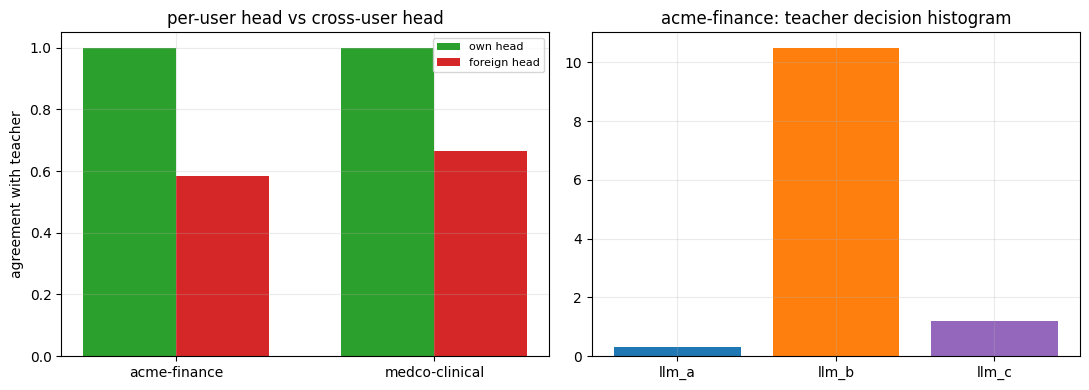

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
labels = ["acme-finance", "medco-clinical"]
own_accs, for_accs = [], []
for ctx in USERS:
    log = registry[ctx.user_id]["result"].routing_log
    own = evaluate_router_on_log(head_fin if ctx.user_id == "acme-finance" else head_med, log)
    foreign = evaluate_router_on_log(head_med if ctx.user_id == "acme-finance" else head_fin, log)
    own_accs.append(own["agreement"]); for_accs.append(foreign["agreement"])

x = np.arange(len(labels))
axes[0].bar(x - 0.18, own_accs, 0.36, label="own head", color="tab:green")
axes[0].bar(x + 0.18, for_accs, 0.36, label="foreign head", color="tab:red")
axes[0].set_xticks(x, labels)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("agreement with teacher")
axes[0].set_title("per-user head vs cross-user head")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

for ax, ctx in zip(axes[1:], USERS):
    hist = registry[ctx.user_id]["metrics"]["teacher_label_histogram"]
    ax.bar(["llm_a", "llm_b", "llm_c"], hist, color=["tab:blue", "tab:orange", "tab:purple"])
    ax.set_title(f"{ctx.user_id}: teacher decision histogram")
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f"{DEFAULT_MODEL_ROOT}/user_heads.png", dpi=110)
plt.show()

## Summary

- **Built-in per-user training now exists** (`trainer/user_models.py`):
  `UserContext` → `VocabAdapter` → `collect_user_dataset` →
  `train_user_head` → `register_user_model` → `UserHeadRouter.load`.
- The apparatus stayed shared and vocabulary-agnostic; only the tiny
  typed head is per-user (a few KB on disk, millisecond CPU inference).
- The registry is a directory per user under `~/.cache/ewm-models/` with
  `config.json` (feature spec), `routing_log.jsonl` (distillation data),
  `typed_head.pt` (model), `metrics.json` (holdout acc/KL).
- The cross-user evaluation shows whether the per-user context actually
  matters: the own head should track its user's teacher better than the
  foreign head does.

Production follow-ups: per-user **codebooks** on the Rust side (smaller
vocabularies make materialization exact — SEPARATION.md), incremental
re-training as a user's `routing_log` grows, reward fine-tuning on loop
surprise, and a model-server that loads `UserHeadRouter`s by user id.